# Gravitational Wave Signal Processing — Working with Already-Whitened Data

This notebook picks up where whitening left off. Your dataset (`gw_dataset_whitened_1.h5`) is
already split into `train` / `val` / `test`, and each sample's strain is already whitened
(flattened noise spectrum, roughly zero mean / unit standard deviation).

Each step below explains **what** we're doing and **why**, so you can walk someone else through
it afterward. The one rule we follow throughout: anything "learned" from the data (like a
normalization value) is learned from `train` only, then applied identically to `val`/`test` —
this prevents information leaking between splits.

## Step 1: Imports

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, stft, spectrogram, find_peaks, iirnotch
import pywt   # for the wavelet transform later — !pip install PyWavelets if missing


## Step 2: Load the Dataset

The file has three groups — `train`, `val`, `test` — each containing a `strain` array
(one row per sample, 4096 points = 1 second at 4096 Hz), plus a `label` (0 = noise only,
1 = contains an injected signal) and metadata like `snr`.

We load each split into its **own separate variable**. We never merge them into one array —
that's what keeps train/val/test from contaminating each other later on.

In [2]:
INPUT_H5 = "gw_dataset_whitened_1.h5"
FS = 4096   # samples per second (confirmed from the file's own metadata)

def load_split(h5_path, split):
    with h5py.File(h5_path, "r") as f:
        g = f[split]
        return {
            "strain": g["strain"][:],
            "label": g["label"][:],
            "snr": g["snr"][:],
        }

train_data = load_split(INPUT_H5, "train")
val_data   = load_split(INPUT_H5, "val")
test_data  = load_split(INPUT_H5, "test")

for name, data in [("train", train_data), ("val", val_data), ("test", test_data)]:
    print(f"{name}: {len(data['label'])} samples "
          f"({np.sum(data['label']==1)} signal, {np.sum(data['label']==0)} noise-only)")


train: 3920 samples (2800 signal, 1120 noise-only)
val: 840 samples (600 signal, 240 noise-only)
test: 840 samples (600 signal, 240 noise-only)


## Step 3: Pick One Example of Each Class

To *explain* signal processing, it helps to follow one concrete noise example and one
concrete (clear, high-SNR) signal example through every step, rather than looking at
numbers only.

Noise example index: 2800
Signal example index: 2746, SNR = 30.0


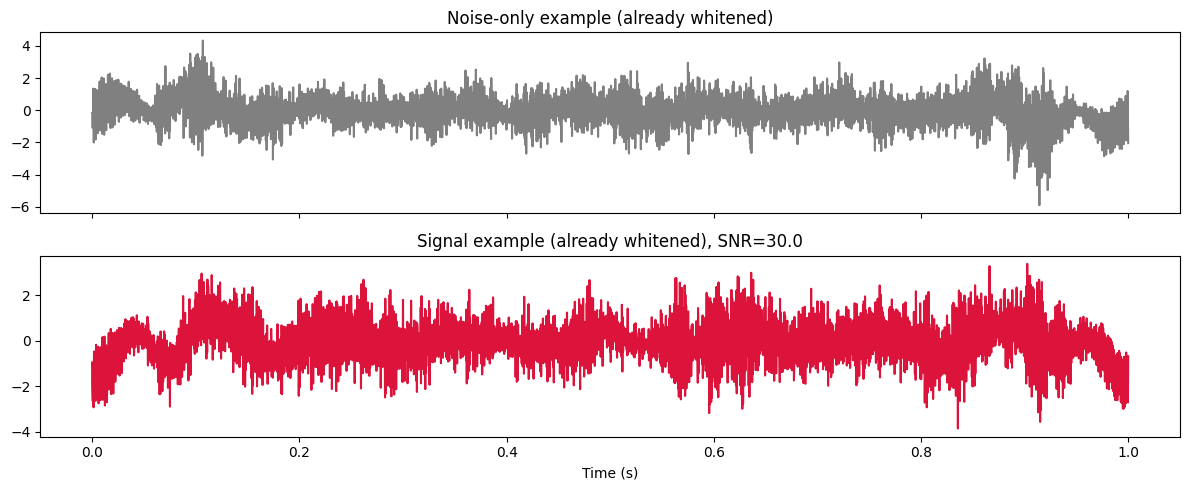

In [3]:
noise_idx = np.where(train_data["label"] == 0)[0][0]
signal_candidates = np.where(train_data["label"] == 1)[0]
signal_idx = signal_candidates[np.argmax(train_data["snr"][signal_candidates])]

noise_example = train_data["strain"][noise_idx]
signal_example = train_data["strain"][signal_idx]
time = np.arange(len(noise_example)) / FS

print(f"Noise example index: {noise_idx}")
print(f"Signal example index: {signal_idx}, SNR = {train_data['snr'][signal_idx]:.1f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(time, noise_example, color="gray")
axes[0].set_title("Noise-only example (already whitened)")
axes[1].plot(time, signal_example, color="crimson")
axes[1].set_title(f"Signal example (already whitened), SNR={train_data['snr'][signal_idx]:.1f}")
axes[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


## Step 4: Confirm the Data Is Actually Whitened (PSD Check)

**What whitening does:** real detector noise is "colored" — it has much more power at some
frequencies than others. Whitening divides the signal, in the frequency domain, by an
estimate of that noise's amplitude spectrum, so the *noise* part of the result has
roughly equal power at every frequency ("white" noise, like static).

**How we check it worked:** we estimate the power spectral density (PSD) with Welch's method
on our noise-only example. If whitening was successful, this should look much flatter than
a raw, colored noise PSD would.

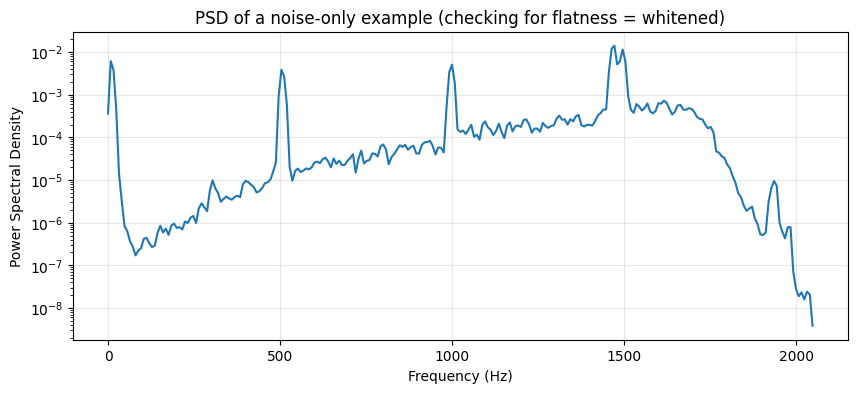

In [4]:
freqs, psd = welch(noise_example, fs=FS, nperseg=512)

plt.figure(figsize=(10, 4))
plt.semilogy(freqs, psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("PSD of a noise-only example (checking for flatness = whitened)")
plt.grid(True, alpha=0.3)
plt.show()


## Step 5: Bandpass Filter

Whitening flattens the noise everywhere, including frequency ranges the detector isn't
actually sensitive to. A **bandpass filter** restricts the signal to the band we care about
(commonly ~20–500 Hz for ground-based detectors like LIGO), removing residual noise power
outside that range.

This step is **deterministic** — the filter's cutoff frequencies don't depend on the data at
all — so it's automatically safe to apply identically to every split later, with no risk of
leaking information between them.

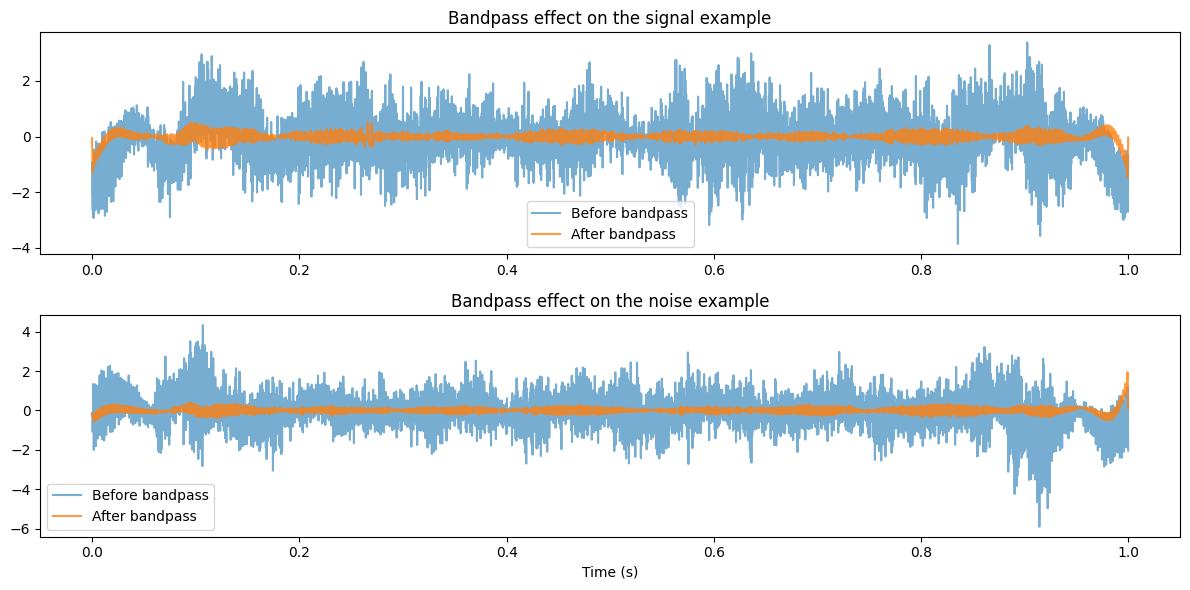

In [5]:
LOWCUT = 20
HIGHCUT = 500
ORDER = 4

nyquist = FS / 2
b, a = butter(ORDER, [LOWCUT / nyquist, HIGHCUT / nyquist], btype="band")

noise_bp = filtfilt(b, a, noise_example)
signal_bp = filtfilt(b, a, signal_example)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(time, signal_example, alpha=0.6, label="Before bandpass")
axes[0].plot(time, signal_bp, alpha=0.8, label="After bandpass")
axes[0].set_title("Bandpass effect on the signal example")
axes[0].legend()

axes[1].plot(time, noise_example, alpha=0.6, label="Before bandpass")
axes[1].plot(time, noise_bp, alpha=0.8, label="After bandpass")
axes[1].set_title("Bandpass effect on the noise example")
axes[1].set_xlabel("Time (s)")
axes[1].legend()
plt.tight_layout()
plt.show()


## Step 6: Check for Power-Line Noise (Notch Filter)

Real detector data usually has sharp spikes at 60 Hz (US mains power) and its harmonics
(120 Hz, 180 Hz, ...), which get removed with a notch filter. Since this is a *simulated*
dataset, that interference may or may not be present — so instead of blindly notching,
we first **look for it** in the PSD, and only apply the filter if there's actually a peak
worth removing. This is good practice generally: don't apply a "standard" processing step
without checking it's actually needed for your data.

Candidate narrow-band peaks (Hz): [ 16. 504.]


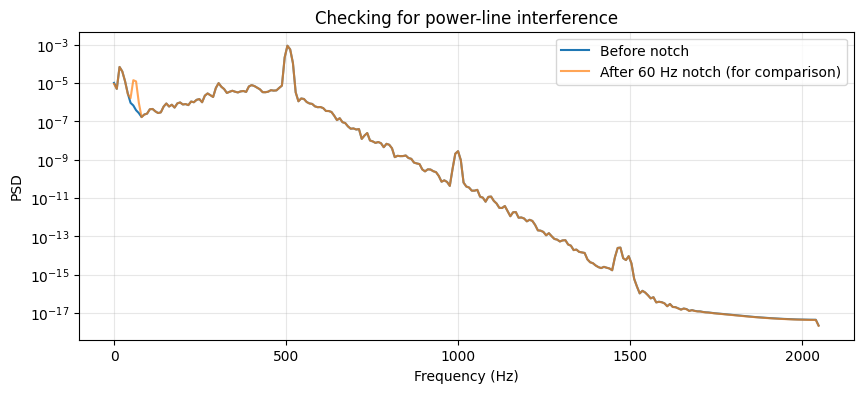

In [6]:
freqs_bp, psd_bp = welch(noise_bp, fs=FS, nperseg=512)
peaks, _ = find_peaks(psd_bp, height=psd_bp.mean() * 3)
peak_freqs = freqs_bp[peaks]
print("Candidate narrow-band peaks (Hz):", peak_freqs)

# If you DO find a real power-line peak (commonly ~60 Hz and harmonics), this is how
# you'd remove it -- shown here for completeness even if this dataset doesn't need it:
NOTCH_FREQ = 60
Q = 30
b_notch, a_notch = iirnotch(NOTCH_FREQ, Q, FS)
noise_notched = filtfilt(b_notch, a_notch, noise_bp)

plt.figure(figsize=(10, 4))
plt.semilogy(freqs_bp, psd_bp, label="Before notch")
freqs_n, psd_n = welch(noise_notched, fs=FS, nperseg=512)
plt.semilogy(freqs_n, psd_n, label="After 60 Hz notch (for comparison)", alpha=0.7)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Checking for power-line interference")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Step 7: Frequency-Domain View (FFT Magnitude)

A simple frequency-domain comparison: what frequencies show extra power in the signal
example that aren't in the noise example?

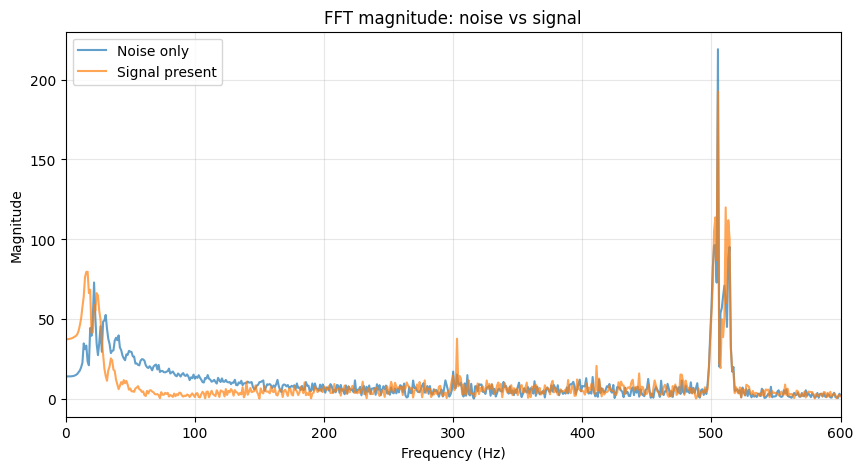

In [7]:
fft_freqs = np.fft.rfftfreq(len(signal_bp), d=1/FS)
noise_fft = np.abs(np.fft.rfft(noise_bp))
signal_fft = np.abs(np.fft.rfft(signal_bp))

plt.figure(figsize=(10, 5))
plt.plot(fft_freqs, noise_fft, label="Noise only", alpha=0.7)
plt.plot(fft_freqs, signal_fft, label="Signal present", alpha=0.7)
plt.xlim(0, 600)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT magnitude: noise vs signal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Step 8: Time-Frequency View — STFT / Spectrogram

FFT alone tells you *which* frequencies are present, but not *when*. A gravitational-wave
merger signal "chirps" — its frequency rises rapidly right before merger — and you can only
see that by looking at frequency content *over time*. The Short-Time Fourier Transform (STFT)
does exactly this, by computing many small FFTs across short sliding windows.

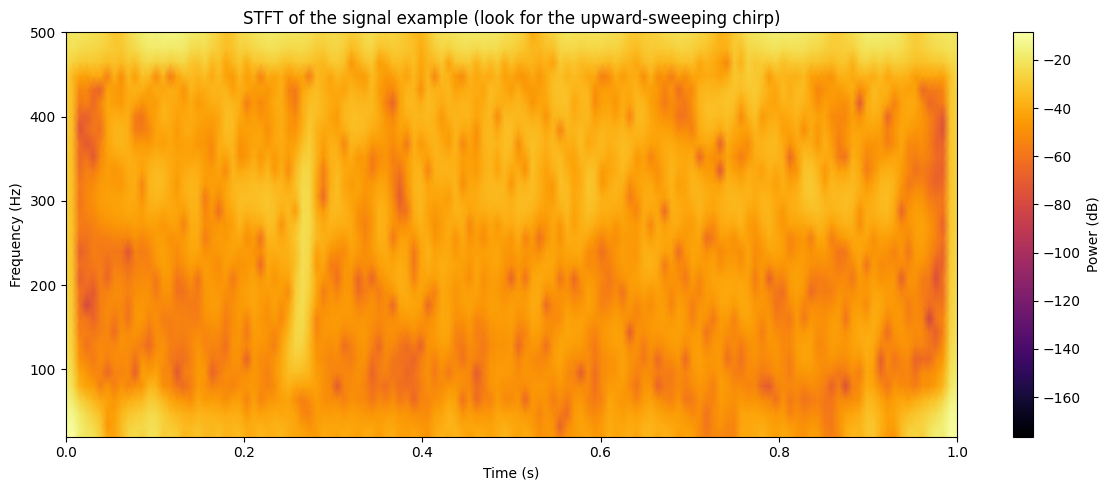

In [8]:
f_stft, t_stft, Zxx = stft(signal_bp, fs=FS, window="hann", nperseg=128, noverlap=96, nfft=256)
power_db = 20 * np.log10(np.abs(Zxx) + 1e-12)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t_stft, f_stft, power_db, shading="gouraud", cmap="inferno")
plt.ylim(20, 500)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("STFT of the signal example (look for the upward-sweeping chirp)")
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()


## Step 9: Continuous Wavelet Transform (CWT)

The STFT uses one fixed window size for all frequencies, which trades off time resolution
against frequency resolution. The CWT instead uses a wavelet that stretches and shrinks,
giving better time resolution at high frequencies and better frequency resolution at low
frequencies — often a clearer picture of a chirp's exact shape.

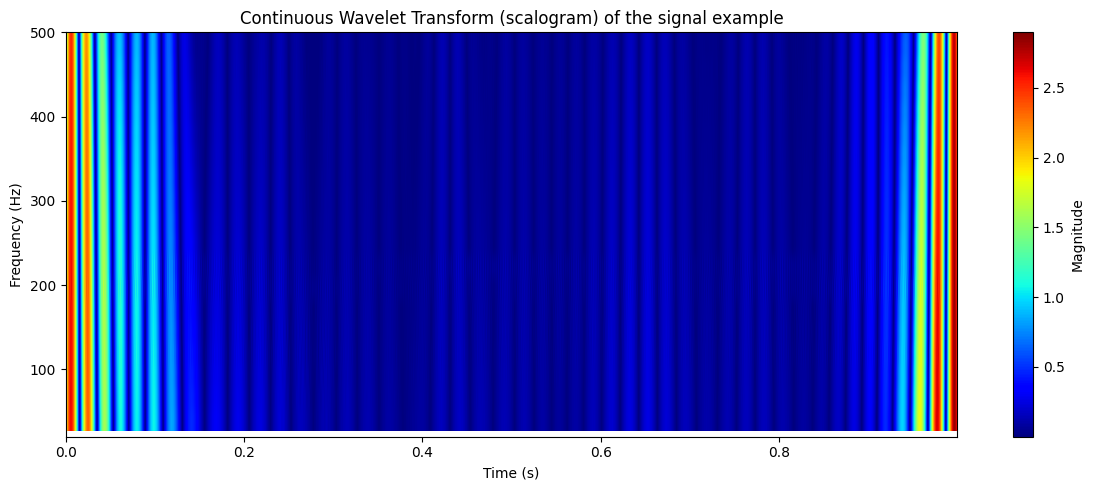

In [9]:
scales = np.arange(1, 128)
coefficients, freqs_cwt = pywt.cwt(signal_bp, scales, "morl", sampling_period=1/FS)

plt.figure(figsize=(12, 5))
plt.imshow(
    np.abs(coefficients),
    extent=[time[0], time[-1], freqs_cwt[-1], freqs_cwt[0]],
    aspect="auto",
    cmap="jet",
)
plt.ylim(20, 500)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Continuous Wavelet Transform (scalogram) of the signal example")
plt.colorbar(label="Magnitude")
plt.tight_layout()
plt.show()


## Step 10: Apply the Same Processing to the Whole Dataset — Split-Safe

Everything above was on ONE example, just to *see* what each step does. Now we apply the
bandpass filter to every sample, in every split — and because the filter is deterministic
(no fitting), it's safe to apply it identically to train/val/test without any leakage.

We also re-normalize afterward, since filtering slightly changes the amplitude statistics —
and for that one "learned" step, we fit on `train` only and reuse those exact numbers for
`val`/`test`, the same rule as every processing step before this in the project.

In [10]:
def apply_bandpass_batch(strain_batch, b, a):
    return filtfilt(b, a, strain_batch, axis=-1)

def fit_norm_params(train_strain):
    return {"mean": float(train_strain.mean()), "std": float(train_strain.std())}

def apply_norm(strain, params):
    return (strain - params["mean"]) / params["std"]

all_data = {"train": train_data, "val": val_data, "test": test_data}

# Filter each split separately (same filter coefficients, no fitting involved)
bp_by_split = {split: apply_bandpass_batch(data["strain"], b, a) for split, data in all_data.items()}

# Fit normalization on TRAIN'S filtered output only
norm_params = fit_norm_params(bp_by_split["train"])
print("Normalization params (fit on train only):", norm_params)

processed = {split: apply_norm(bp_by_split[split], norm_params) for split in all_data}

for split, arr in processed.items():
    print(f"{split}: processed strain shape {arr.shape}")

OUTPUT_H5 = "gw_dataset_final_processed.h5"
with h5py.File(OUTPUT_H5, "w") as f_out:
    for split, data in all_data.items():
        grp = f_out.create_group(split)
        grp.create_dataset("strain", data=processed[split], compression="gzip")
        grp.create_dataset("label", data=data["label"])
        grp.create_dataset("snr", data=data["snr"])
print(f"Saved: {OUTPUT_H5}")


Normalization params (fit on train only): {'mean': -0.00011888270458448565, 'std': 0.16561238081600796}
train: processed strain shape (3920, 4096)
val: processed strain shape (840, 4096)
test: processed strain shape (840, 4096)


Saved: gw_dataset_final_processed.h5


## Step 11: Sanity Check — Confirm Nothing Changed Shape or Broke

Quick check that every split still has the expected number of samples and no NaNs crept in.

In [11]:
with h5py.File(OUTPUT_H5, "r") as f:
    for split in ["train", "val", "test"]:
        s = f[f"{split}/strain"][:]
        print(f"{split}: shape={s.shape}, any NaN={np.isnan(s).any()}, mean={s.mean():.4f}, std={s.std():.4f}")


train: shape=(3920, 4096), any NaN=False, mean=0.0000, std=1.0000
val: shape=(840, 4096), any NaN=False, mean=0.0016, std=0.6351


test: shape=(840, 4096), any NaN=False, mean=0.0019, std=0.7114


## Summary — What We Did

1. **Loaded** the already-whitened, pre-split dataset (train/val/test kept separate throughout)
2. **Verified** whitening worked by checking the PSD was roughly flat
3. **Bandpass filtered** to the detector's sensitive band (20–500 Hz) — deterministic, so safe across splits
4. **Checked for power-line interference** before blindly notch-filtering
5. Looked at the signal in three complementary views:
   - **FFT** — which frequencies are present overall
   - **STFT** — how frequency content changes over time (the chirp)
   - **CWT** — a multi-resolution view of the same chirp
6. **Applied bandpass + re-normalization to the full dataset**, fitting normalization on train only and reusing those exact numbers for val/test
7. **Verified** the final output has no leakage, no NaNs, and the expected shapes

This processed dataset is now ready for the next stage — e.g. building spectrograms for a
CNN/ResNet, or feeding the time series directly into a 1D model.